In [1]:
from pathlib import Path
import pygimli as pg  # Stelle sicher, dass das Modul pg importiert ist und verfügbar ist
from pygimli.physics import ert
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime
import os
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker

from Hilfsfunktionen import T_corr_nach_Inversion
from Hilfsfunktionen import plotting_function
from Hilfsfunktionen import plotting_function_FTL

# Read data
file = "two_timesteps.ohm"
base_dir = Path("filtered_data")
data = []
for unterordner in base_dir.iterdir():
    if unterordner.is_dir():
        datei_pfad = unterordner / "two_timesteps.ohm" 
        if datei_pfad.exists():
            daten_objekt = pg.load(str(datei_pfad))
            data.append([unterordner.name, daten_objekt])
            print(f"Load data: {datei_pfad}")

# Create method manager
manager = []
for ts in data:
    manager.append(ert.ERTManager(ts[1], verbose=True))

Load data: filtered_data\240610\two_timesteps.ohm
Load data: filtered_data\240704\two_timesteps.ohm


[NbConvertApp] Converting notebook Hilfsfunktionen.ipynb to script
[NbConvertApp] Writing 24887 bytes to Hilfsfunktionen.py


In [6]:
# Create mesh
mesh = manager[0].createMesh(quality = 34, paraMaxCellSize=0.5, paraDepth=15)
#manager[0].invert(quality = 34, paraMaxCellSize=0.5, maxIter=1 ,dPhi= 0.1, paraDepth=15,lam=20)

28/08/25 - 14:23:50 - pyGIMLi - INFO - Found 2 regions.
28/08/25 - 14:23:50 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.


In [7]:
# FTL
manager_list_tl = []
# ScaleF-Liste
scalef_list = np.linspace(0.05, 1.9, num=50)



results_tl_diff = []
chi2_dict_FTL      = []
phi_m_dict_FTL     = []
phi_d_dict_FTL     = []
rms_dict_FTL       = []
rrms_dict_FTL      = []
phi_m_zeitlich     = []


# Inversion without temperature correction
DATA = [dat[1] for dat in data]
# Full time-lapse
for scalef in scalef_list:
    fop = pg.frameworks.MultiFrameModelling(ert.ERTModelling, scalef=scalef)
    fop.setData(DATA)
    fop.setMesh(mesh)
    print(fop.mesh()) 
    dataVec = np.concatenate([data["rhoa"] for data in DATA])
    errorVec = np.concatenate([data["err"] for data in DATA])
    startModel = fop.createStartModel(dataVec)
    inv = pg.Inversion(fop=fop, startModel=startModel, verbose=True)
    model = inv.run(dataVec, errorVec, maxIter=10, lam= 10, startModel=startModel, verbose=True)
    chi2 = []
    rrms = []
    chi2.append(round(inv.chi2(),2))
    rrms.append(round(inv.relrms(),2))
    mod = np.reshape(model, [len(DATA), -1])

    # Zeitliche Roughness berechnen
    m = np.array(inv.model)          # Länge 6208
    n = m.size // 2                    # Zellen je Zeitschritt = 3104
    m1 = m[:n]                         # Schritt 1
    m2 = m[n:]                         # Schritt 2
    
    # falls m bereits log(ρ) wäre: die nächste Zeile weglassen!
    dlog = np.log(m2) - np.log(m1)     # Differenz in log(ρ)
    
    MT = np.sum(dlog**2)               # zeitliche Rauigkeit (L2)

    
    chi2_dict_FTL.append(inv.chi2())
    phi_m_zeitlich.append(MT)
    phi_d_dict_FTL.append(inv.phiData())
    phi_m_dict_FTL.append(inv.phiModel())
    rrms_dict_FTL.append(round(inv.relrms(), 2))
    rms_dict_FTL.append(round(inv.absrms(), 2))


28/08/25 - 14:24:41 - pyGIMLi - INFO - Found 2 regions.
28/08/25 - 14:24:41 - pyGIMLi - INFO - Region with smallest marker (1) set to background
28/08/25 - 14:24:41 - pyGIMLi - INFO - Creating forward mesh from region infos.
28/08/25 - 14:24:41 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
28/08/25 - 14:24:42 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736


3104 model cells
Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736


28/08/25 - 14:24:48 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.frameworks.timelapse.MultiFrameModelling object at 0x000001DBA137B010>
Data transformation: <pgcore._pygimli_.RTrans object at 0x000001DBB691ECE0>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x000001DBB66C7970>
min/max (data): 21.65/1126
min/max (error): 8.7%/10.15%
min/max (start model): 107/107
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  109.55
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   10.45 (dPhi = 88.49%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    4.97 (dPhi = 41.50%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    4.21 (dPhi = 3.88%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 4 ... 

28/08/25 - 14:29:04 - pyGIMLi - INFO - Found 2 regions.
28/08/25 - 14:29:04 - pyGIMLi - INFO - Region with smallest marker (1) set to background
28/08/25 - 14:29:05 - pyGIMLi - INFO - Creating forward mesh from region infos.


...

fop: <pygimli.frameworks.timelapse.MultiFrameModelling object at 0x000001DBBCC72ED0>
Data transformation: <pgcore._pygimli_.RTrans object at 0x000001DBB697CF90>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x000001DBB66C76F0>
min/max (data): 21.65/1126
min/max (error): 8.7%/10.15%
min/max (start model): 107/107
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  109.55
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   10.58 (dPhi = 88.37%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    5.15 (dPhi = 40.02%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    4.36 (dPhi = 3.65%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 4 ... 

28/08/25 - 18:47:09 - pyGIMLi - INFO - Found 2 regions.
28/08/25 - 18:47:09 - pyGIMLi - INFO - Region with smallest marker (1) set to background
28/08/25 - 18:47:09 - pyGIMLi - INFO - Creating forward mesh from region infos.


chi² =    4.31 (dPhi = 0.18%) lam: 10.0
################################################################################
#                Abort criterion reached: dPhi = 0.18 (< 2.0%)                 #
################################################################################


28/08/25 - 18:47:10 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
28/08/25 - 18:47:11 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
28/08/25 - 18:47:14 - pyGIMLi - INFO - Starting inversion.


3104 model cells
Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
fop: <pygimli.frameworks.timelapse.MultiFrameModelling object at 0x000001DBB606CE50>
Data transformation: <pgcore._pygimli_.RTrans object at 0x000001DBB697CEB0>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x000001DBA137ADE0>
min/max (data): 21.65/1126
min/max (error): 8.7%/10.15%
min/max (start model): 107/107
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  109.55
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   10.58 (dPhi = 88.36%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    5.15 (dPhi = 39.99%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    4.37 (dPhi = 3.65%) lam: 10.0
--------------------------------------------------------------------------------
inv.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import UnivariateSpline
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

def plot_l_curve(phi_m_list, phi_d_list, lam_list, spline_s=0.001, fontsize=14, save_path=None):
    """
    L-Curve Plot mit Curvature und Maximum Curvature Annotation.

    Parameters:
    -----------
    phi_m_list : array-like
        Liste der Modell-Roughness-Werte (Φₘ).
    phi_d_list : array-like
        Liste der Daten-Misfit-Werte (Φ_d).
    lam_list : array-like
        Liste der Regularisierungsparameter λ.
    spline_s : float
        Glättungsfaktor für UnivariateSpline (default=0.001).
    fontsize : int
        Schriftgröße für Achsen, Titel, Legende und Annotation.
    """
    fig, ax1 = plt.subplots(1, 1, figsize=(8,6))

    # ==========================
    # L-Curve Plot
    # ==========================
    ax1.plot(phi_m_list, phi_d_list, color='black', marker='o', alpha=0.5, linestyle='')

    sc = ax1.scatter(phi_m_list, phi_d_list,
                     c=lam_list,
                     cmap='jet',
                     norm=mcolors.LogNorm(vmin=min(lam_list), vmax=max(lam_list)),
                     s=60,
                     edgecolor='black',
                     zorder=3)

    cbar = fig.colorbar(sc, ax=ax1)
    cbar.set_label("Regularization parameter sf", fontsize=fontsize)
    num_ticks = 6
    tick_values = np.logspace(np.log10(min(lam_list)), np.log10(max(lam_list)), num=num_ticks)
    cbar.locator = mticker.FixedLocator(tick_values)
    cbar.ax.set_yticklabels([f"{val:.3g}" for val in tick_values], fontsize=fontsize)
    cbar.ax.minorticks_off()

    ax1.set_xlabel("Temporal model roughness $Φ_m$", fontsize=fontsize)
    ax1.set_ylabel("Data misfit $Φ_d$ ", fontsize=fontsize)
    ax1.set_title("L-curve FTL", fontsize=fontsize+2)

    # Tick-Labels größer machen
    ax1.tick_params(axis='both', labelsize=fontsize)

    # ==========================
    # Krümmung berechnen
    # ==========================
    x = (phi_m_list - np.min(phi_m_list)) / (np.max(phi_m_list) - np.min(phi_m_list))
    y = (phi_d_list - np.min(phi_d_list)) / (np.max(phi_d_list) - np.min(phi_d_list))
    t = np.arange(len(x))

    spl_x = UnivariateSpline(t, x, k=3, s=spline_s*len(t))
    spl_y = UnivariateSpline(t, y, k=3, s=spline_s*len(t))

    dx_disc, ddx_disc = spl_x.derivative(1)(t), spl_x.derivative(2)(t)
    dy_disc, ddy_disc = spl_y.derivative(1)(t), spl_y.derivative(2)(t)
    curv_disc = np.abs(dx_disc*ddy_disc - dy_disc*ddx_disc) / (dx_disc**2 + dy_disc**2)**1.5

    # ==========================
    # Zweite Achse für Curvature ohne Beschriftung
    # ==========================
    ax1_curv = ax1.twinx()
    ax1_curv.set_ylabel('')               
    ax1_curv.set_yticklabels([])          
    ax1_curv.tick_params(axis='y', length=5)  

    # Kreuze auf Curvature-Höhe, letzte 10 Punkte weggeschnitten
    phi_m_plot = phi_m_list[:-15]
    curv_plot = curv_disc[:-15]

    ax1_curv.scatter(phi_m_plot, curv_plot,
                     s=60,
                     marker='x',
                     color='black')

    # ==========================
    # Eine gemeinsame Legende (Kreise + Kreuze)
    # ==========================
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='L-Curve', markerfacecolor='black', markersize=8, alpha=0.5, linestyle='None'),
        Line2D([0], [0], marker='x', color='black', label='Curvature', markersize=8, linestyle='None')
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=fontsize)

    # ==========================
    # Maximalpunkt markieren mit Pfeil von rechts oben
    # ==========================
    idx_max_curv = np.argmax(curv_plot)
    phi_m_max = phi_m_plot[idx_max_curv]
    curv_max = curv_plot[idx_max_curv]
    lam_max = lam_list[idx_max_curv]

    ax1_curv.annotate(f"Maximum curvature\nat sf={lam_max:.1g}",
                     xy=(phi_m_max+5, curv_max*0.97),
                     xytext=(phi_m_max + 30, curv_max*0.79),
                     arrowprops=dict(facecolor='black', arrowstyle="->"),
                     ha='center',
                     color='black',
                     fontsize=fontsize)
    #
    plt.tight_layout()
    # ==========================
    # Optional speichern
    # ==========================
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")

    plt.show()


In [4]:
import numpy as np

# Arrays normal laden
phi_m_zeitlich = np.load('./L_curve_FTL/L-Curve_zwei_Zeitschritte_phi_m_zeitlich.npy')
scalef_list = np.load('./L_curve_FTL/L-Curve_zwei_Zeitschritte_scalef_list_2.npy')

# Dict laden (Pickle notwendig!)
phi_d_dict_FTL = np.load('./L_curve_FTL/L-Curve_zwei_Zeitschritte_phi_d_mean_new_2.npy')


Figure saved to ./L_curve_FTL/L-Curve_zwei_Zeitschritte_gute_Darstellung_groesser.png


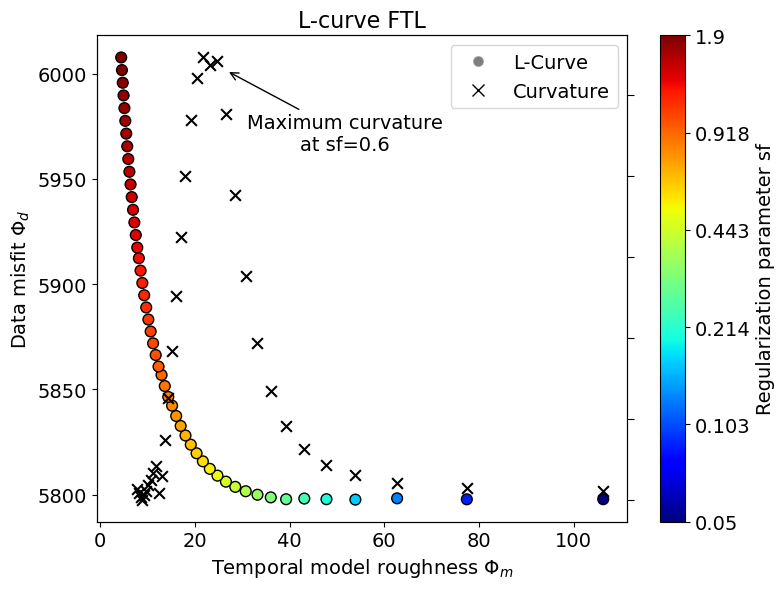

In [5]:
plot_l_curve(phi_m_zeitlich, phi_d_dict_FTL, scalef_list, spline_s=0.001, fontsize=14, save_path='./L_curve_FTL/L-Curve_zwei_Zeitschritte_gute_Darstellung_groesser.png')

#np.save('./L_curve_FTL/L-Curve_zwei_Zeitschritte_phi_m_zeitlich.npy', phi_m_zeitlich)
#np.save('./L_curve_FTL/L-Curve_zwei_Zeitschritte_phi_d_mean_new_2.npy', phi_d_dict_FTL)
#np.save('./L_curve_FTL/L-Curve_zwei_Zeitschritte_scalef_list_2.npy', scalef_list)